DMN generated at: dmn_output.dmn
Graphviz tree saved as: decision_tree_graphviz.png


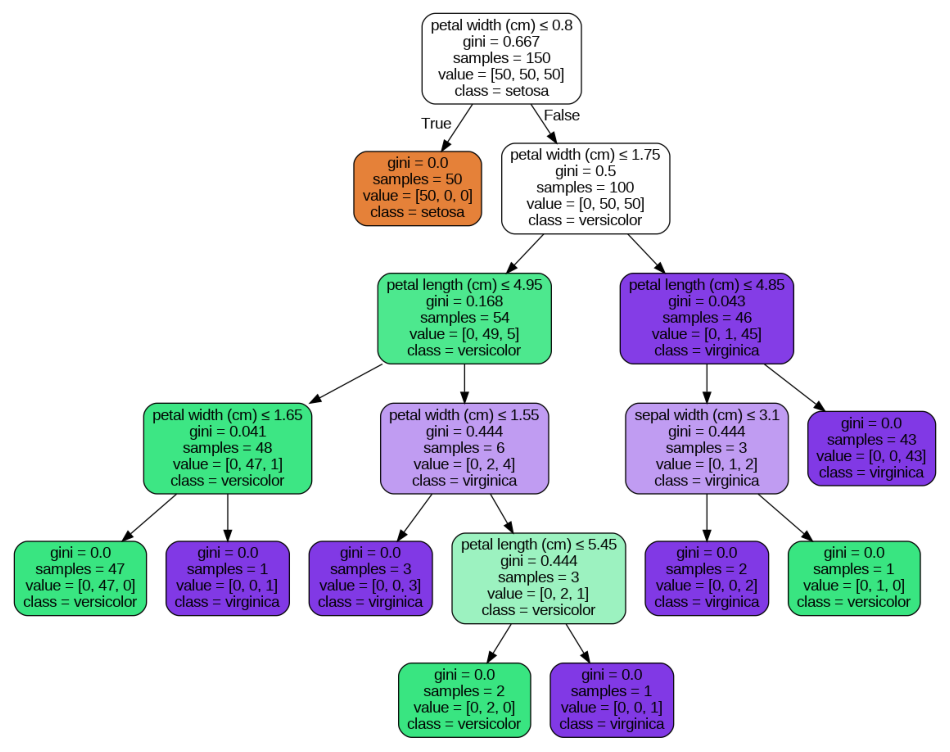

In [ ]:
# Το script κάνει τα εξής:
# 1. Εκπαιδεύει ένα Decision Tree πάνω στο dataset Iris
# 2. Διαβάζει τη δομή του δέντρου (κόμβοι, thresholds, φύλλα)
# 3. Μετατρέπει κάθε leaf του δέντρου σε έναν κανόνα IF–THEN
# 4. Δημιουργεί ένα DMN XML αρχείο (Decision Model & Notation)
# 5. Παράγει και εικόνα του Decision Tree με Graphviz


import time
import random
import numpy as np
import pandas as pd
import xml.etree.ElementTree as et
from collections import defaultdict
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from PIL import Image


# ============================================================
# Κλάση xmlDmn
# ------------------------------------------------------------
# Υπεύθυνη για:
# - Δημιουργία της βασικής δομής DMN XML
# - Ορισμό input / output στηλών
# - Δημιουργία κανόνων (<rule>) στον decision table
# - Αποθήκευση του τελικού DMN αρχείου
# ============================================================

class xmlDmn:

    # --------------------------------------------------------
    # Constructor
    # --------------------------------------------------------
    # Δημιουργεί τη βασική δομή ενός DMN αρχείου:
    # <definitions>
    #   <decision>
    #     <decisionTable>
    # --------------------------------------------------------
    def __init__(self):
        # Namespace του DMN (σύμφωνα με το OMG standard)
        self.dmn_ns = "http://www.omg.org/spec/DMN/20151101/dmn.xsd"

        # Root element: <definitions>
        self.root = et.Element(
            "{%s}definitions" % self.dmn_ns,
            {
                "id": "definitions_1",
                "name": "Decision Model",
                "namespace": "http://example.org/dmn",
                "xmlns:dmn": self.dmn_ns,
            },
        )

        # <decision>
        self.decision = et.SubElement(
            self.root,
            "{%s}decision" % self.dmn_ns,
            {"id": "decision_1", "name": "Decision"},
        )

        # <decisionTable>
        self.decisionTableElement = et.SubElement(
            self.decision,
            "{%s}decisionTable" % self.dmn_ns,
            {"id": "decisionTable_1", "hitPolicy": "UNIQUE"},
        )

        # Μετρητής για μοναδικά IDs σε XML στοιχεία
        self._id_counter = 0

    # --------------------------------------------------------
    # Δημιουργία μοναδικού ID για XML elements
    # --------------------------------------------------------
    def idGen(self, prefix):
        self._id_counter += 1
        return f"{prefix}{self._id_counter}"

    # --------------------------------------------------------
    # Δημιουργία στηλών (inputs & output) του DMN πίνακα
    # --------------------------------------------------------
    # names:
    #   [feature1, feature2, ..., featureN, outputName]
    # --------------------------------------------------------
    def generateTableColumns(self, names):
        # Το τελευταίο όνομα θεωρείται output
        outputName = names[-1]
        inputNames = names[:-1]

        # Δημιουργία input στηλών
        for name in inputNames:
            newInput = et.SubElement(
                self.decisionTableElement,
                "{%s}input" % self.dmn_ns,
                {"id": self.idGen("input_")},
            )

            # Κάθε input έχει ένα inputExpression
            newInputExpression = et.SubElement(
                newInput,
                "{%s}inputExpression" % self.dmn_ns,
                {"id": self.idGen("inputExpression_"), "typeRef": "double"},
            )

            # Το <text> περιέχει το όνομα του feature
            newText = et.SubElement(newInputExpression, "{%s}text" % self.dmn_ns)
            newText.text = name

        # Δημιουργία output στήλης
        et.SubElement(
            self.decisionTableElement,
            "{%s}output" % self.dmn_ns,
            {"id": self.idGen("output_"), "name": outputName, "typeRef": "string"},
        )

    # --------------------------------------------------------
    # Δημιουργία ενός κελιού inputEntry μέσα σε rule
    # --------------------------------------------------------
    def createRuleCell(self, ruleElement, text=""):
        # <inputEntry>
        cell = et.SubElement(
            ruleElement,
            "{%s}inputEntry" % self.dmn_ns,
            {"id": self.idGen("inputEntry_")},
        )

        # <text> του κελιού (π.χ. "> 2.45" ή "<= 5.1")
        t = et.SubElement(cell, "{%s}text" % self.dmn_ns)
        t.text = text
        return cell

    # --------------------------------------------------------
    # Μετατροπή κανόνων IF–THEN σε DMN <rule>

    def generateTableRows(self, mIDict):
        for k, v in mIDict:
            # Δημιουργία νέου rule
            newRule = et.SubElement(
                self.decisionTableElement,
                "{%s}rule" % self.dmn_ns,
                {"id": self.idGen("rule_")},
            )

            # Για κάθε feature δημιουργούμε ένα inputEntry
            for keyFeature in v:
                signDict = v[keyFeature]
                tSignList = list(signDict.keys())

                # Καμία συνθήκη -> κενό κελί ("-")
                if len(signDict) == 0:
                    self.createRuleCell(newRule, "")
                    continue

                # Μία συνθήκη (<= ή >)
                if len(signDict) == 1:
                    s = tSignList[0]
                    val = signDict[s]
                    if s == "<=":
                        self.createRuleCell(newRule, f"<= {val:.4f}")
                    else:
                        self.createRuleCell(newRule, f"> {val:.4f}")
                    continue

                # Δύο συνθήκες -> εύρος τιμών
                if len(signDict) == 2 and (">" in signDict) and ("<=" in signDict):
                    low = signDict[">"]
                    high = signDict["<="]
                    self.createRuleCell(newRule, f"]{low:.4f}..{high:.4f}]")
                    continue

                # Οποιαδήποτε άλλη περίπτωση
                self.createRuleCell(newRule, "")

            # Output του rule (κλάση)
            newOutEntry = et.SubElement(
                newRule,
                "{%s}outputEntry" % self.dmn_ns,
                {"id": self.idGen("LiteralExpression_")},
            )
            newOutText = et.SubElement(newOutEntry, "{%s}text" % self.dmn_ns)
            newOutText.text = str(k)

    # --------------------------------------------------------
    # Εγγραφή του DMN XML σε αρχείο
    # --------------------------------------------------------
    def writeTree(self, filename="dmn_output.dmn"):
        tree = et.ElementTree(self.root)
        tree.write(filename, encoding="utf-8", xml_declaration=True)
        return filename


# ============================================================
# Κλάση clfDmn
# ------------------------------------------------------------
# Παίρνει ένα εκπαιδευμένο DecisionTreeClassifier και:
# - Εντοπίζει όλα τα leaf nodes
# - Ανακατασκευάζει τις συνθήκες (IF) από τη ρίζα έως το leaf
# - Παράγει DMN κανόνες (THEN = κλάση leaf)
# ============================================================

class clfDmn:

    def __init__(self, clf=None, df=None, featureColNames=None, classColName=None):
        self.clf = clf              # Εκπαιδευμένο Decision Tree
        self.df = df                # Αρχικό DataFrame

        self.dfFeature = featureColNames
        self.dfClassColumn = classColName

        # Μόνο τα αριθμητικά features (για decision_path)
        self.dfData = df[featureColNames].values

        # Αντικείμενο για δημιουργία DMN XML
        self.xml = xmlDmn()

    # --------------------------------------------------------
    # Καθαρίζει τον decision table (πριν τον ξαναγεμίσουμε)
    # --------------------------------------------------------
    def clearDecisionTable(self):
        for child in list(self.xml.decisionTableElement):
            self.xml.decisionTableElement.remove(child)

    # --------------------------------------------------------
    # Μετατροπή Decision Tree -> DMN Decision Table
    # --------------------------------------------------------
    def generateTableFromClf(self):
        tree_ = self.clf.tree_
        leafChildren_left = tree_.children_left
        leafChildren_right = tree_.children_right
        thresholds = tree_.threshold

        # Features + output κλάση
        featuresForDiagram = list(self.dfFeature)
        featuresForDiagram.append(self.dfClassColumn)

        # Δημιουργία στηλών DMN
        self.clearDecisionTable()
        self.xml.generateTableColumns(featuresForDiagram)

        # decision_path: ποιοι κόμβοι διασχίζονται από κάθε δείγμα
        decPath = self.clf.decision_path(self.dfData)

        # Εντοπισμός leaf nodes
        leafIds = np.where(
            (leafChildren_left == -1) & (leafChildren_right == -1)
        )[0]

        # Για κάθε leaf node δημιουργούμε έναν κανόνα
        for i in set(leafIds):
            # Δείγματα που περνάνε από αυτό το leaf
            samplesInNode = decPath.getcol(i).copy()
            rows = samplesInNode.nonzero()[0]
            if len(rows) == 0:
                continue

            # Παίρνουμε ένα αντιπροσωπευτικό δείγμα
            sampleId = rows[0]

            # Κόμβοι που διασχίζει το δείγμα
            nodeIndex = decPath.indices[
                decPath.indptr[sampleId] : decPath.indptr[sampleId + 1]
            ]

            inputOutput = defaultdict(dict)

            # Κλάση του leaf (argmax των πιθανοτήτων)
            class_index = int(np.argmax(self.clf.tree_.value[i]))
            className = self.clf.classes_[class_index]
            inputOutput[className] = {}

            # Αρχικοποίηση όλων των features χωρίς συνθήκες
            for feat in featuresForDiagram[:-1]:
                inputOutput[className][feat] = {}

            # Ανακατασκευή των IF συνθηκών
            for idx_pos in range(len(nodeIndex) - 1):
                node_id = nodeIndex[idx_pos]
                feat_idx = tree_.feature[node_id]
                if feat_idx < 0:
                    continue

                feat_name = self.dfFeature[feat_idx]
                node_threshold = float(thresholds[node_id])

                next_node = nodeIndex[idx_pos + 1]
                if next_node == leafChildren_left[node_id]:
                    inputOutput[className][feat_name]["<="] = node_threshold
                elif next_node == leafChildren_right[node_id]:
                    inputOutput[className][feat_name][">"] = node_threshold

            # Δημιουργία DMN rule για αυτό το leaf
            self.xml.generateTableRows([
                (className, inputOutput[className])
            ])

        # Αποθήκευση DMN αρχείου
        return self.xml.writeTree("dmn_output.dmn")


# ============================================================
# MAIN SCRIPT
# ------------------------------------------------------------
# 1. Φόρτωση Iris dataset
# 2. Εκπαίδευση Decision Tree
# 3. Μετατροπή σε DMN
# 4. Οπτικοποίηση του δέντρου
# ============================================================

if __name__ == "__main__":
    from sklearn.datasets import load_iris

    # Φόρτωση δεδομένων Iris
    iris = load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)

    # Χρήση ονομάτων κλάσεων (setosa, versicolor, virginica)
    df["class"] = iris.target_names[iris.target]

    # Εκπαίδευση Decision Tree γίνεται με τη κλήση της μεθόδου fit
    clf = DecisionTreeClassifier(random_state=0)
    clf.fit(df[iris.feature_names].values, df["class"].values)

    # Wrapper για μετατροπή σε DMN
    wrapper = clfDmn(
        clf=clf,
        df=df,
        featureColNames=iris.feature_names,
        classColName="class",
    )

    # Δημιουργία DMN αρχείου
    dmn_path = wrapper.generateTableFromClf()
    print("DMN generated at:", dmn_path)

    # Εξαγωγή του Decision Tree σε Graphviz
    dot_data = tree.export_graphviz(
        clf,
        out_file=None,
        feature_names=iris.feature_names,
        class_names=iris.target_names,
        filled=True,
        rounded=True,
        impurity=True,
        special_characters=True,
    )

    graph = graphviz.Source(dot_data)
    output_img = "decision_tree_graphviz"
    graph.format = "png"
    graph.render(output_img, cleanup=True)

    print("Graphviz tree saved as:", output_img + ".png")

    # Εμφάνιση της εικόνας
    img = Image.open(output_img + ".png")
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
